# 6CS012 – Final Integrated Assessment
## Part III: Text Classification with RNN, LSTM, and Word2Vec
### Dataset: Racist / Sexist Tweet Classification

**Herald College Kathmandu | University of Wolverhampton**

| | |
|---|---|
| **Student Name** | Dipendra Roka |
| **WLV ID** | 2418541 |
| **Group** | L6CG18 |
| **Group Members** | Dipendra Roka, Shubham Raj Pandey, Dipesh Paharai, Asmit Pradhan |
| **Module** | 6CS012 – Artificial Intelligence and Machine Learning |
| **Task** | Sentiment Analysis of Tweets (Racist/Sexist vs Non-Hate) |

---

### Notebook Outline
1. Setup & Library Installation
2. Dataset Loading
3. Exploratory Data Analysis (class imbalance check!)
4. Text Cleaning Pipeline
5. Visualisation (Word Cloud, Top words)
6. Tokenisation, Padding, Stratified Split
7. **Model 1** – Simple RNN (trainable embedding)
8. **Model 2** – Bidirectional LSTM (trainable embedding)
9. **Model 3** – Bidirectional LSTM + GloVe (pretrained embedding)
10. Threshold tuning for best F1 on imbalanced data
11. Final comparison of all three models
12. Error analysis (misclassified examples)
13. Gradio GUI for real-time prediction

---
**Important note on the dataset:**
This is a **heavily imbalanced** binary classification problem
(roughly **93% non-hate, 7% hate**). Plain accuracy is misleading
— a model that always predicts "non-hate" gets ~93% accuracy and
is useless. We therefore optimise and report **macro-F1** and tune
the decision threshold on the validation set.


---
## Section 1 – Setup & Imports


In [4]:
# ── Install third-party libraries (Colab usually has the rest) ──
!pip install -q contractions wordcloud gensim gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.3 MB/s eta 0:00:00


In [3]:
import sys
!{sys.executable} -m pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.7 MB/s eta 0:00:00


In [5]:
# ── Core imports ──────────────────────────────────────────────────────────────
import os, re, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Bidirectional,
                                     Dense, Dropout, SpatialDropout1D,
                                     BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers, optimizers

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# ── Download NLTK resources ───────────────────────────────────────────────────
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("NLTK resources downloaded.")

NLTK resources downloaded.


---
## Section 2 – Dataset Loading

Mount Google Drive and load the train CSV. The test CSV has no labels (it's
the Kaggle holdout) so we'll only use the **train CSV**, splitting it
ourselves into train / val / test.


In [7]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import zipfile

ZIP_PATH = "/content/drive/MyDrive/AI folder/Assetment/Text/set.zip"
EXTRACT_DIR = "/content/dataset"

# Create the extraction directory if it doesn't exist
os.makedirs(EXTRACT_DIR, exist_ok=True)

print(f"Checking if zip file exists: {os.path.exists(ZIP_PATH)}")

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print(f"'{ZIP_PATH}' unzipped to '{EXTRACT_DIR}'.")
else:
    print(f"Error: Zip file not found at '{ZIP_PATH}'. Please ensure the path is correct.")

Checking if zip file exists: True
'/content/drive/MyDrive/AI folder/Assetment/Text/set.zip' unzipped to '/content/dataset'.


In [9]:
print(f"Listing contents of the extracted directory: {EXTRACT_DIR}")
for root, dirs, files in os.walk(EXTRACT_DIR):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Listing contents of the extracted directory: /content/dataset
/content/dataset/7. Racist Sexist or Not Dataset
/content/dataset/7. Racist Sexist or Not Dataset/train_racisit.csv
/content/dataset/7. Racist Sexist or Not Dataset/test_racisit.csv
/content/dataset/7. Racist Sexist or Not Dataset/7.Description Racist - Sexist or Not.txt


In [10]:
# Update paths to point to the unzipped files
TRAIN_PATH = "/content/dataset/7. Racist Sexist or Not Dataset/train_racisit.csv"
TEST_PATH  = "/content/dataset/7. Racist Sexist or Not Dataset/test_racisit.csv"

print(f"Train file exists: {os.path.exists(TRAIN_PATH)}")
print(f"Test  file exists: {os.path.exists(TEST_PATH)}")

Train file exists: True
Test  file exists: True


In [11]:
# ── Load the labelled training CSV ────────────────────────────────────────────
df = pd.read_csv(TRAIN_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (31962, 3)
Columns: ['id', 'label', 'tweet']


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


---
## Section 3 – Exploratory Data Analysis

We need to understand:
- How big is the class imbalance?
- How long are the tweets?
- Are there missing values?


In [12]:
# ── Basic info & nulls ────────────────────────────────────────────────────────
print("===== Dataset Info =====")
print(df.info())
print("\n===== Missing values =====")
print(df.isnull().sum())
print("\n===== Label values =====")
print(df['label'].unique())

===== Dataset Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB
None

===== Missing values =====
id       0
label    0
tweet    0
dtype: int64

===== Label values =====
[0 1]


label
0    29720
1     2242
Name: count, dtype: int64

Class 0 (non-hate)  :  29720  (92.99%)
Class 1 (hate)      :   2242  (7.01%)
Imbalance ratio     : 13.3 : 1


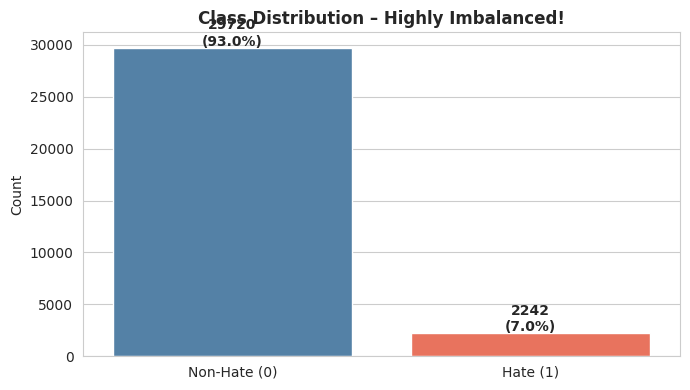

In [13]:
# ── Class distribution (THE most important plot for this dataset) ─────────────
class_counts = df['label'].value_counts().sort_index()
print(class_counts)
print(f"\nClass 0 (non-hate)  : {class_counts[0]:>6}  ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Class 1 (hate)      : {class_counts[1]:>6}  ({class_counts[1]/len(df)*100:.2f}%)")
print(f"Imbalance ratio     : {class_counts[0] / class_counts[1]:.1f} : 1")

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=['Non-Hate (0)', 'Hate (1)'], y=class_counts.values,
                 palette=['steelblue', 'tomato'])
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 200, f'{v}\n({v/len(df)*100:.1f}%)',
            ha='center', fontweight='bold')
plt.title('Class Distribution – Highly Imbalanced!', fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

count    31962.00000
mean        13.15872
std          5.47815
min          3.00000
25%          9.00000
50%         13.00000
75%         17.00000
max         34.00000
Name: raw_len, dtype: float64


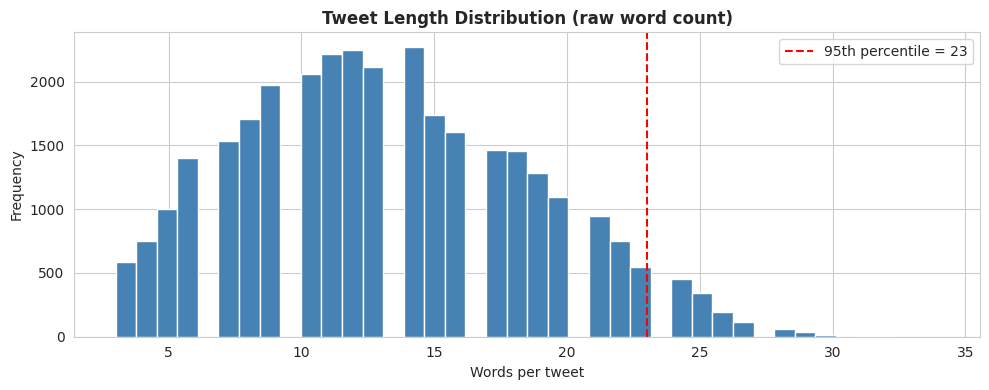

In [14]:
# ── Tweet length distribution ─────────────────────────────────────────────────
df['raw_len'] = df['tweet'].str.split().str.len()
print(df['raw_len'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['raw_len'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(df['raw_len'].quantile(0.95), color='red', linestyle='--',
            label=f"95th percentile = {df['raw_len'].quantile(0.95):.0f}")
plt.title('Tweet Length Distribution (raw word count)', fontweight='bold')
plt.xlabel('Words per tweet')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('tweet_length.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 4 – Text Cleaning Pipeline

For each tweet we:
1. Expand contractions (`don't` → `do not`)
2. Lowercase
3. Remove URLs, mentions (`@user`), hashtag symbols, numbers
4. Strip punctuation and non-ASCII (emojis etc.)
5. Tokenise → remove stopwords → lemmatise
6. Drop consecutive duplicate words


In [15]:
# ── Stopwords + lemmatiser ────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
stop_words.add('user')                              # the dataset masks @mentions as "user"
lemmatizer = WordNetLemmatizer()

URL_RE     = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@[A-Za-z0-9_]+')
HASHTAG_RE = re.compile(r'#')
NUMBER_RE  = re.compile(r'\d+')
NON_ASCII  = re.compile(r'[^\x00-\x7F]+')
PUNCT_RE   = re.compile(r'[^\w\s]')

def clean_tweet(text):
    if not isinstance(text, str):
        return ""
    text = contractions.fix(text)
    text = text.lower()
    text = URL_RE.sub(' ', text)
    text = MENTION_RE.sub(' ', text)
    text = HASHTAG_RE.sub('', text)            # keep word, drop '#'
    text = NUMBER_RE.sub(' ', text)
    text = NON_ASCII.sub(' ', text)
    text = PUNCT_RE.sub(' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens
              if t not in stop_words and len(t) > 1]
    # drop consecutive duplicates ("lol lol lol" -> "lol")
    deduped, prev = [], None
    for tok in tokens:
        if tok != prev:
            deduped.append(tok)
        prev = tok
    return ' '.join(deduped)

# Sanity check
test_examples = [
    "@user when a father is dysfunctional and is selfish #parents 123",
    "I LOVE THIS!!! Don't you?? https://example.com",
    "thanks #model #love love love yeahhhh"
]
for ex in test_examples:
    print(f"BEFORE: {ex}")
    print(f"AFTER : {clean_tweet(ex)}\n")

BEFORE: @user when a father is dysfunctional and is selfish #parents 123
AFTER : father dysfunctional selfish parent

BEFORE: I LOVE THIS!!! Don't you?? https://example.com
AFTER : love

BEFORE: thanks #model #love love love yeahhhh
AFTER : thank model love yeahhhh



In [16]:
# ── Apply cleaning to whole dataset ───────────────────────────────────────────
print("Cleaning all tweets...")
t0 = time.time()
df['cleaned'] = df['tweet'].apply(clean_tweet)
print(f"Done in {time.time()-t0:.1f}s")

# Drop empty cleaned tweets (some tweets become empty after stopword removal)
empty = (df['cleaned'].str.strip() == '').sum()
print(f"Empty after cleaning: {empty}")
df = df[df['cleaned'].str.strip() != ''].reset_index(drop=True)
print(f"Remaining rows: {len(df)}")

df[['tweet', 'cleaned', 'label']].head(5)

Cleaning all tweets...
Done in 1.6s
Empty after cleaning: 41
Remaining rows: 31921


,tweet,cleaned,label
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...,0
1,@user @user thanks for #lyft credit i can't us...,thank lyft credit cannot use offer wheelchair ...,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in ...,model love take time,0
4,factsguide: society now #motivation,factsguide society motivation,0


---
## Section 5 – Visualising the Cleaned Text

Word cloud + top-20 frequent words for each class.


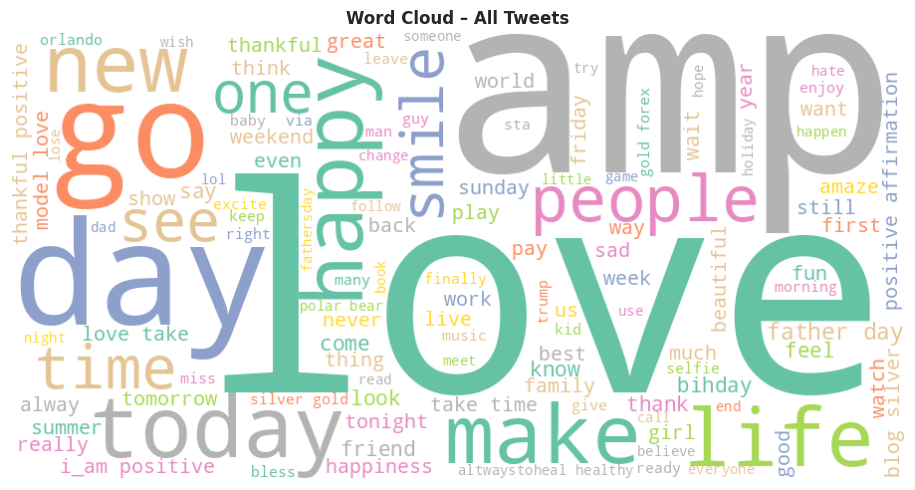

In [17]:
# ── Word cloud (all data) ─────────────────────────────────────────────────────
all_text = ' '.join(df['cleaned'])
wc = WordCloud(width=900, height=450, background_color='white',
               max_words=120, colormap='Set2').generate(all_text)
plt.figure(figsize=(11, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud – All Tweets', fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_all.png', dpi=120, bbox_inches='tight')
plt.show()

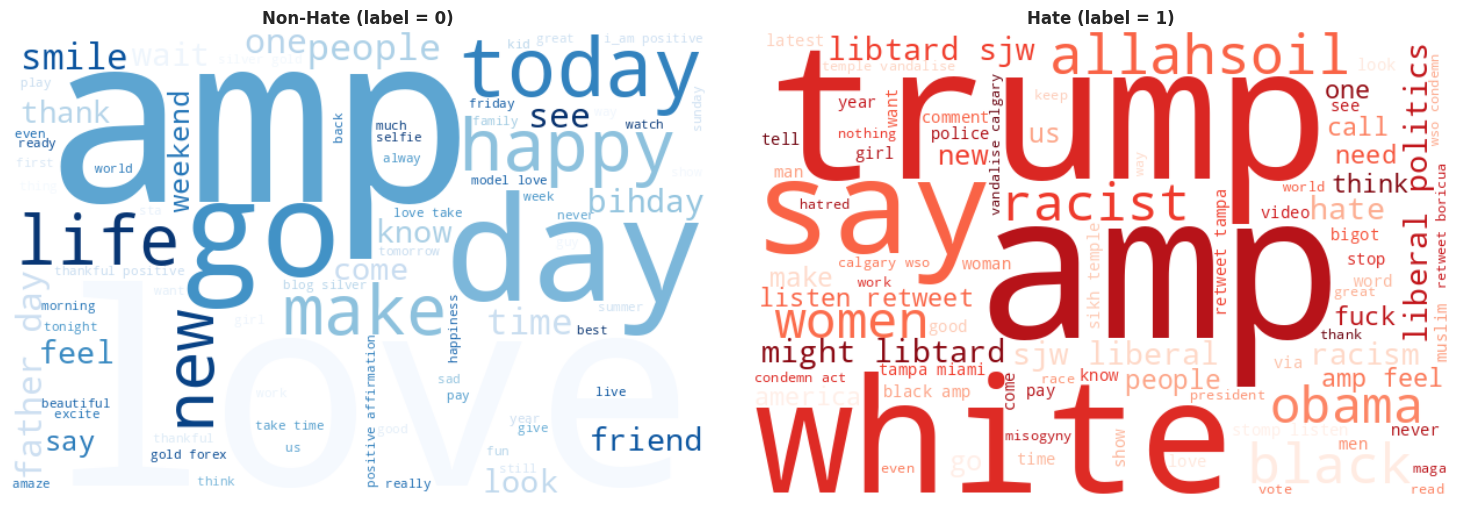

In [18]:
# ── Word clouds per class ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, (label, name) in enumerate([(0, 'Non-Hate'), (1, 'Hate')]):
    text = ' '.join(df[df['label'] == label]['cleaned'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=80, colormap='Blues' if label == 0 else 'Reds').generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{name} (label = {label})', fontweight='bold')
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('wordcloud_per_class.png', dpi=120, bbox_inches='tight')
plt.show()

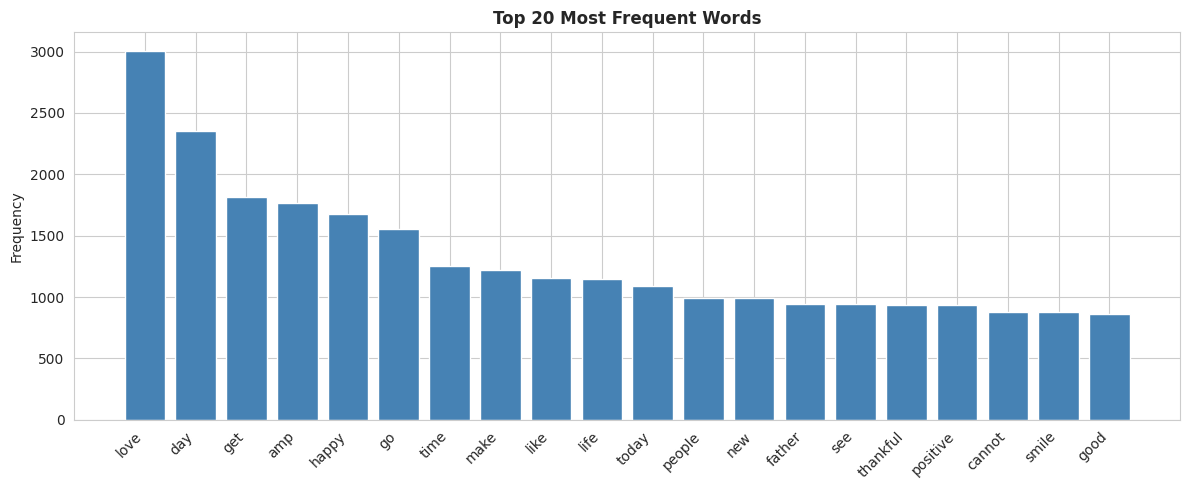

In [19]:
# ── Top 20 most frequent words ────────────────────────────────────────────────
words = ' '.join(df['cleaned']).split()
top20 = dict(Counter(words).most_common(20))

plt.figure(figsize=(12, 5))
plt.bar(top20.keys(), top20.values(), color='steelblue', edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words', fontweight='bold')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('top20_words.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 6 – Tokenisation, Padding & Stratified Split

- 80% train / 10% val / 10% test, **stratified** by label so all splits keep the same imbalance.
- Tokeniser fit on **train only** (no leakage from val/test).
- Padding length = **95th percentile** of cleaned-tweet length (avoids wasting compute on a few outlier tweets).


In [20]:
# ── 6.1 Stratified split: 80% train / 10% val / 10% test ──────────────────────
X = df['cleaned'].values
y = df['label'].values

# First split off 10% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=SEED
)
# Then split remaining 90% into 88.9/11.1 -> overall 80/10
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, stratify=y_temp, random_state=SEED
)

print(f"Train : {len(X_train):>5}  | hate ratio: {y_train.mean():.3f}")
print(f"Val   : {len(X_val):>5}  | hate ratio: {y_val.mean():.3f}")
print(f"Test  : {len(X_test):>5}  | hate ratio: {y_test.mean():.3f}")

Train : 25539  | hate ratio: 0.070
Val   :  3189  | hate ratio: 0.070
Test  :  3193  | hate ratio: 0.070


In [21]:
# ── 6.2 Fit tokeniser on TRAIN ONLY ───────────────────────────────────────────
MAX_VOCAB = 20_000
OOV_TOKEN = '<OOV>'

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)
vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f"Vocabulary size used: {vocab_size}")

# Convert text -> integer sequences
seq_train = tokenizer.texts_to_sequences(X_train)
seq_val   = tokenizer.texts_to_sequences(X_val)
seq_test  = tokenizer.texts_to_sequences(X_test)

Vocabulary size used: 20000


In [22]:
# ── 6.3 Percentile-based padding length ───────────────────────────────────────
seq_lens = [len(s) for s in seq_train]
MAX_LEN = int(np.percentile(seq_lens, 95))
MAX_LEN = max(MAX_LEN, 10)        # never below 10
print(f"95th percentile sequence length = {MAX_LEN}")

X_train_pad = pad_sequences(seq_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(seq_val,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(seq_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Padded shapes -> train: {X_train_pad.shape}, val: {X_val_pad.shape}, test: {X_test_pad.shape}")

95th percentile sequence length = 13
Padded shapes -> train: (25539, 13), val: (3189, 13), test: (3193, 13)


In [23]:
# ── 6.4 Class weights for the imbalanced classes ──────────────────────────────
class_w = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_w)}
print(f"Class weights: {class_weight_dict}")
# -> hate class will get a much higher weight, forcing the model to pay attention

Class weights: {0: np.float64(0.5376857972967283), 1: np.float64(7.133798882681564)}


In [24]:
# ── 6.5 Common training hyperparameters ───────────────────────────────────────
EMBED_DIM   = 100
BATCH_SIZE  = 64
EPOCHS      = 15

def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=3,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, verbose=1),
        ModelCheckpoint(f'best_{name}.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

---
## Section 7 – Model 1: Simple RNN (trainable embedding)

Architecture deliberately kept simple per the assignment brief (the
assignment requires a SimpleRNN). Regularised with SpatialDropout +
recurrent_dropout to fight overfitting on the small minority class.


In [25]:
# ── 7.1 Build & train RNN ────────────────────────────────────────────────────
model_rnn = Sequential(name='SimpleRNN_Model')
model_rnn.add(Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                        input_length=MAX_LEN, mask_zero=True))
model_rnn.add(SpatialDropout1D(0.4)) # Increased from 0.3
model_rnn.add(SimpleRNN(64, dropout=0.4, recurrent_dropout=0.3)) # Increased from 0.3 and 0.2
model_rnn.add(Dense(32, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)))
model_rnn.add(Dropout(0.5)) # Increased from 0.4
model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(optimizer=optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Explicitly build the model before printing the summary
model_rnn.build(input_shape=(None, MAX_LEN))
model_rnn.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 13, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,012,673 (7.68 MB)

 Trainable params: 2,012,673 (7.68 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
print("Training Simple RNN...\n")
t0 = time.time()
hist_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('rnn'),
    verbose=1
)
time_rnn = time.time() - t0
print(f"\nRNN training time: {time_rnn/60:.2f} min")

Training Simple RNN...

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.5645 - loss: 0.6854 - val_accuracy: 0.8692 - val_loss: 0.4409 - learning_rate: 0.0010
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8500 - loss: 0.4164 - val_accuracy: 0.9229 - val_loss: 0.2344 - learning_rate: 0.0010
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9132 - loss: 0.2787 - val_accuracy: 0.9225 - val_loss: 0.2235 - learning_rate: 0.0010
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9339 - loss: 0.2020 - val_accuracy: 0.9294 - val_loss: 0.2043 - learning_rate: 0.0010
Epoch 5/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9504 - loss: 0.1594 - val_accuracy: 0.9257 - val_loss: 0.2019 - learning_rate: 0.0010
Epoch 6/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9576 - loss: 0.1279 - val_accuracy: 0.9458 - val_loss: 0.1867 - learning_rate: 0.0010
Epoch 7/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy

---
## Section 8 – Model 2: Bidirectional LSTM (trainable embedding)

Bidirectional gives the model context from both directions of the tweet,
which usually helps a lot for short text like tweets.


In [27]:
# ── 8.1 Build & train LSTM ───────────────────────────────────────────────────
model_lstm = Sequential(name='BiLSTM_Model')
model_lstm.add(Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                         input_length=MAX_LEN, mask_zero=True))
model_lstm.add(SpatialDropout1D(0.3))
model_lstm.add(Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.2)))
model_lstm.add(Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)))
model_lstm.add(BatchNormalization())
model_lstm.add(Dropout(0.4))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(optimizer=optimizers.Adam(1e-3),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
model_lstm.build(input_shape=(None, MAX_LEN))
model_lstm.summary()

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 13, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,088,769 (7.97 MB)

 Trainable params: 2,088,705 (7.97 MB)

 Non-trainable params: 64 (256.00 B)

In [28]:
print("Training BiLSTM...\n")
t0 = time.time()
hist_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('lstm'),
    verbose=1
)
time_lstm = time.time() - t0
print(f"\nLSTM training time: {time_lstm/60:.2f} min")

Training BiLSTM...

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.7531 - loss: 0.4799 - val_accuracy: 0.9599 - val_loss: 0.2736 - learning_rate: 0.0010
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 53s 133ms/step - accuracy: 0.9240 - loss: 0.2377 - val_accuracy: 0.9498 - val_loss: 0.1702 - learning_rate: 0.0010
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 84s 138ms/step - accuracy: 0.9625 - loss: 0.1462 - val_accuracy: 0.9470 - val_loss: 0.1767 - learning_rate: 0.0010
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9740 - loss: 0.1084
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
400/400 ━━━━━━━━━━━━━━━━━━━━ 82s 138ms/step - accuracy: 0.9768 - loss: 0.0970 - val_accuracy: 0.9586 - val_loss: 0.1746 - learning_rate: 0.0010
Epoch 5/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 57s 142ms/step - accuracy: 0.9831 - loss: 0.0723 - val_accuracy: 0.9404 - val_loss: 0.2255 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights 

---
## Section 9 – Model 3: Bidirectional LSTM + Pretrained GloVe Embeddings

We use `glove-twitter-100` from gensim — GloVe vectors **trained on
2 billion tweets**, so they're tailor-made for our Twitter dataset.
The embedding layer is **frozen** so we use it as-is.


In [29]:
# ── 9.1 Download a Twitter-trained word vector (100-dim, ~390 MB) ─────────────

import gensim.downloader as api
print("Downloading glove-twitter-100 ... (only first time, ~390MB)")
w2v = api.load("glove-twitter-100")
print(f"Vector dimension: {w2v.vector_size}")
print(f"Vocabulary size:  {len(w2v):,}")

[==================================================] 100.0% 387.1/387.1MB downloaded
Vector dimension: 100
Vocabulary size:  1,193,514


In [30]:
# ── 9.2 Build embedding matrix aligned with our tokenizer ─────────────────────
EMBED_DIM_W2V = 100
embedding_matrix = np.zeros((vocab_size, EMBED_DIM_W2V))

found = 0
for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v:
        embedding_matrix[idx] = w2v[word]
        found += 1

coverage = found / (vocab_size - 1) * 100
print(f"Words with pretrained vector: {found}/{vocab_size-1} ({coverage:.1f}%)")

Words with pretrained vector: 14203/19999 (71.0%)


In [32]:
model_w2v = Sequential(name='BiLSTM_GloVe_Model')
model_w2v.add(Embedding(input_dim=vocab_size, output_dim=EMBED_DIM_W2V,
                        weights=[embedding_matrix], input_length=MAX_LEN,
                        trainable=False, mask_zero=True))
model_w2v.add(SpatialDropout1D(0.3))
model_w2v.add(Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.2)))
model_w2v.add(Dense(32, activation='relu',
                    kernel_regularizer=regularizers.l2(0.001)))
model_w2v.add(BatchNormalization())
model_w2v.add(Dropout(0.4))
model_w2v.add(Dense(1, activation='sigmoid'))

model_w2v.compile(optimizer=optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model_w2v.build(input_shape=(None, MAX_LEN))
model_w2v.summary()

Model: "BiLSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 13, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 13, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,088,769 (7.97 MB)

 Trainable params: 88,705 (346.50 KB)

 Non-trainable params: 2,000,064 (7.63 MB)

In [33]:
print("Training BiLSTM + GloVe...\n")
t0 = time.time()
hist_w2v = model_w2v.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('w2v'),
    verbose=1
)
time_w2v = time.time() - t0
print(f"\nW2V model training time: {time_w2v/60:.2f} min")

Training BiLSTM + GloVe...

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 66s 147ms/step - accuracy: 0.6596 - loss: 0.6184 - val_accuracy: 0.8511 - val_loss: 0.4148 - learning_rate: 0.0010
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 51s 127ms/step - accuracy: 0.7905 - loss: 0.4781 - val_accuracy: 0.8768 - val_loss: 0.3723 - learning_rate: 0.0010
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 50s 124ms/step - accuracy: 0.8110 - loss: 0.4421 - val_accuracy: 0.8893 - val_loss: 0.3282 - learning_rate: 0.0010
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - accuracy: 0.8222 - loss: 0.4224 - val_accuracy: 0.8639 - val_loss: 0.3580 - learning_rate: 0.0010
Epoch 5/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8237 - loss: 0.4113
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
400/400 ━━━━━━━━━━━━━━━━━━━━ 50s 124ms/step - accuracy: 0.8284 - loss: 0.3940 - val_accuracy: 0.8683 - val_loss: 0.3475 - learning_rate: 0.0010
Epoch 6/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 51s 

---
## Section 10 – Threshold Tuning (the secret to good F1 on imbalanced data)

The default `0.5` cut-off is rarely optimal on imbalanced data. We sweep
thresholds **on the validation set** and pick the one that maximises
F1 for the positive (hate) class. We then evaluate on the held-out
test set with that locked threshold — which is a clean, leak-free
evaluation protocol.


In [34]:
# ── 10.1 Helper to find best threshold on validation ─────────────────────────
def best_threshold(model, X_val, y_val):
    probs = model.predict(X_val, verbose=0).flatten()
    precisions, recalls, thresholds = precision_recall_curve(y_val, probs)
    # f1 for each threshold (avoid div-by-zero)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1s[:-1])           # last entry has no threshold
    return float(thresholds[best_idx]), float(f1s[best_idx])

thr_rnn,  f1_val_rnn  = best_threshold(model_rnn,  X_val_pad, y_val)
thr_lstm, f1_val_lstm = best_threshold(model_lstm, X_val_pad, y_val)
thr_w2v,  f1_val_w2v  = best_threshold(model_w2v,  X_val_pad, y_val)

print(f"RNN     -> best thr = {thr_rnn:.3f}  (val F1 = {f1_val_rnn:.4f})")
print(f"LSTM    -> best thr = {thr_lstm:.3f}  (val F1 = {f1_val_lstm:.4f})")
print(f"W2V LSTM-> best thr = {thr_w2v:.3f}  (val F1 = {f1_val_w2v:.4f})")

RNN     -> best thr = 0.894  (val F1 = 0.7100)
LSTM    -> best thr = 0.807  (val F1 = 0.7169)
W2V LSTM-> best thr = 0.843  (val F1 = 0.6494)



===== Simple RNN  (threshold=0.894) =====
Accuracy        : 0.9593
Precision (hate): 0.7527
Recall    (hate): 0.6250
F1        (hate): 0.6829
Macro F1        : 0.8306

Classification report:
              precision    recall  f1-score   support

    Non-Hate     0.9721    0.9845    0.9782      2969
        Hate     0.7527    0.6250    0.6829       224

    accuracy                         0.9593      3193
   macro avg     0.8624    0.8048    0.8306      3193
weighted avg     0.9567    0.9593    0.9575      3193



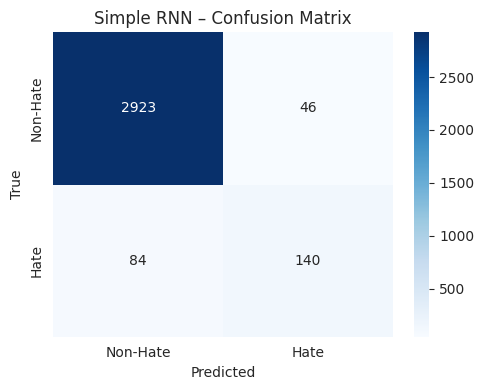


===== BiLSTM  (threshold=0.807) =====
Accuracy        : 0.9590
Precision (hate): 0.7541
Recall    (hate): 0.6161
F1        (hate): 0.6781
Macro F1        : 0.8281

Classification report:
              precision    recall  f1-score   support

    Non-Hate     0.9714    0.9848    0.9781      2969
        Hate     0.7541    0.6161    0.6781       224

    accuracy                         0.9590      3193
   macro avg     0.8628    0.8005    0.8281      3193
weighted avg     0.9562    0.9590    0.9570      3193



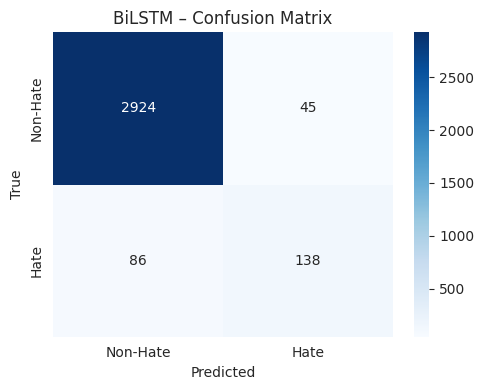


===== BiLSTM + GloVe  (threshold=0.843) =====
Accuracy        : 0.9455
Precision (hate): 0.6068
Recall    (hate): 0.6339
F1        (hate): 0.6201
Macro F1        : 0.7954

Classification report:
              precision    recall  f1-score   support

    Non-Hate     0.9723    0.9690    0.9706      2969
        Hate     0.6068    0.6339    0.6201       224

    accuracy                         0.9455      3193
   macro avg     0.7896    0.8015    0.7954      3193
weighted avg     0.9467    0.9455    0.9461      3193



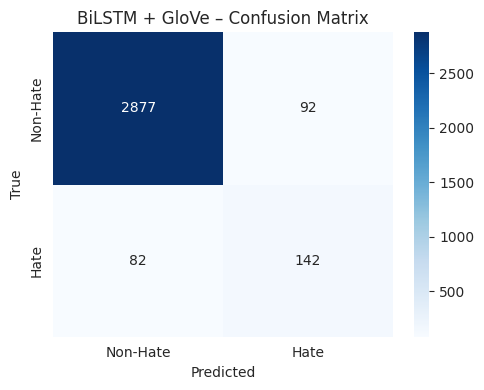

In [35]:
# ── 10.2 Evaluate each model on TEST set with its tuned threshold ─────────────
def evaluate(model, X_test, y_test, thr, name):
    probs = model.predict(X_test, verbose=0).flatten()
    y_pred = (probs >= thr).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    macf = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"\n===== {name}  (threshold={thr:.3f}) =====")
    print(f"Accuracy        : {acc:.4f}")
    print(f"Precision (hate): {prec:.4f}")
    print(f"Recall    (hate): {rec:.4f}")
    print(f"F1        (hate): {f1:.4f}")
    print(f"Macro F1        : {macf:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred,
          target_names=['Non-Hate', 'Hate'], digits=4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Hate', 'Hate'],
                yticklabels=['Non-Hate', 'Hate'])
    plt.title(f'{name} – Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ", "_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

    return {'name': name, 'acc': acc, 'prec': prec, 'rec': rec,
            'f1_hate': f1, 'macro_f1': macf, 'thr': thr}

res_rnn  = evaluate(model_rnn,  X_test_pad, y_test, thr_rnn,  'Simple RNN')
res_lstm = evaluate(model_lstm, X_test_pad, y_test, thr_lstm, 'BiLSTM')
res_w2v  = evaluate(model_w2v,  X_test_pad, y_test, thr_w2v,  'BiLSTM + GloVe')

---
## Section 11 – Final Comparison


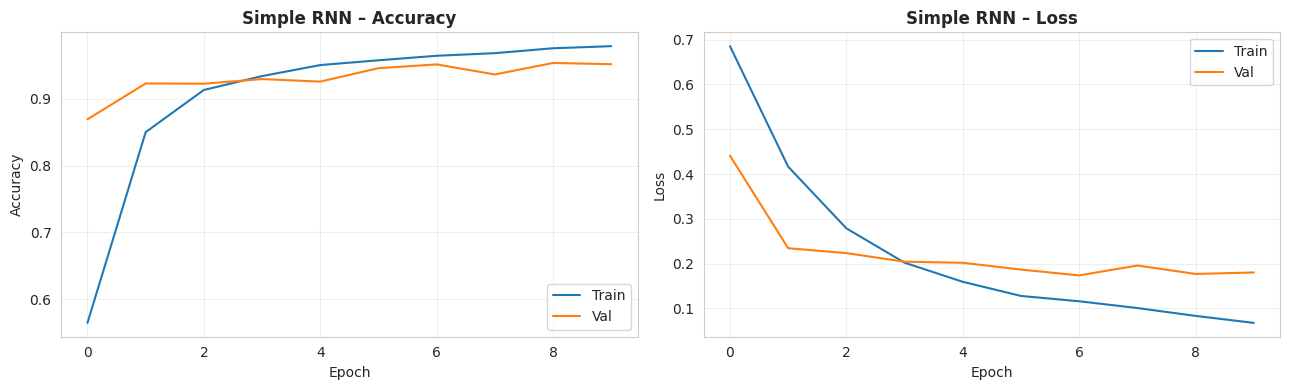

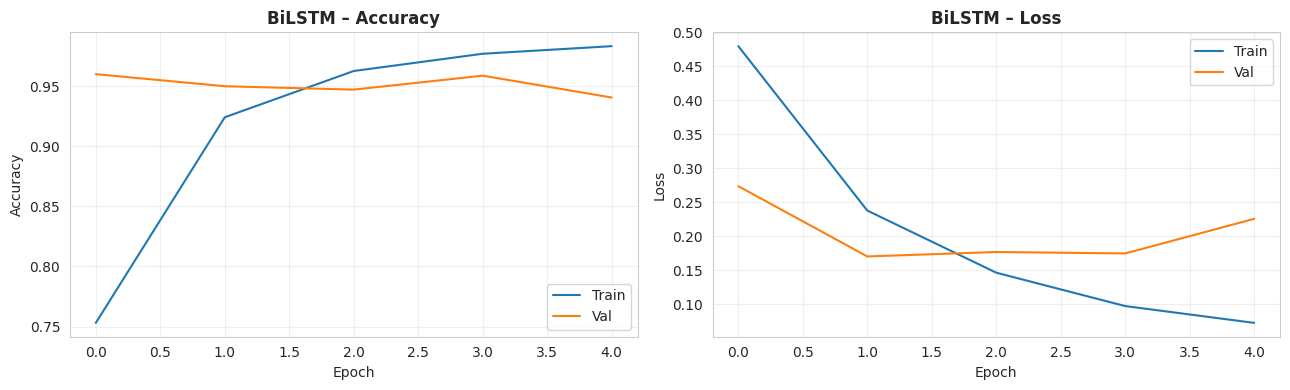

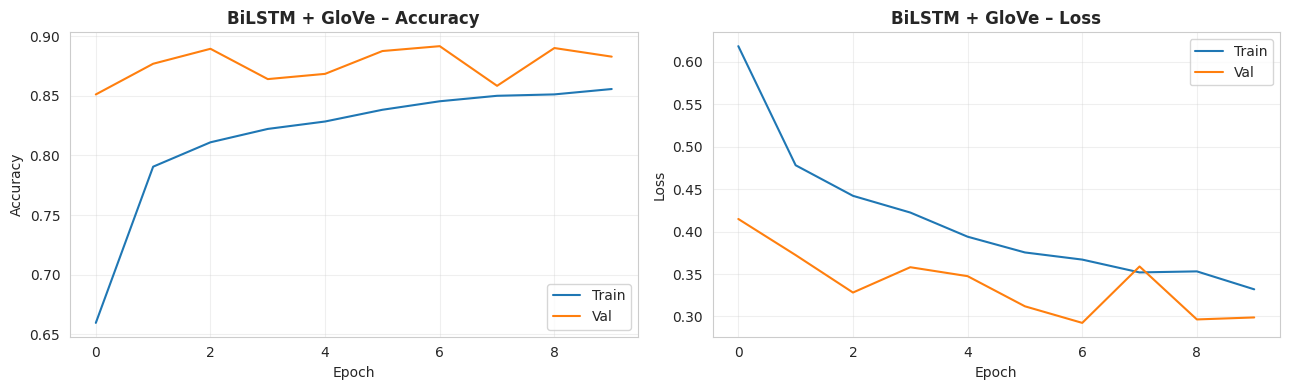

In [36]:
# ── 11.1 Plot training curves for all three models ────────────────────────────
def plot_curves(history, name):
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(history.history['accuracy'],     label='Train')
    axs[0].plot(history.history['val_accuracy'], label='Val')
    axs[0].set_title(f'{name} – Accuracy', fontweight='bold')
    axs[0].set_xlabel('Epoch'); axs[0].set_ylabel('Accuracy')
    axs[0].legend(); axs[0].grid(alpha=.3)

    axs[1].plot(history.history['loss'],     label='Train')
    axs[1].plot(history.history['val_loss'], label='Val')
    axs[1].set_title(f'{name} – Loss', fontweight='bold')
    axs[1].set_xlabel('Epoch'); axs[1].set_ylabel('Loss')
    axs[1].legend(); axs[1].grid(alpha=.3)
    plt.tight_layout()
    plt.savefig(f'curves_{name.replace(" ", "_").replace("+", "")}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

plot_curves(hist_rnn,  'Simple RNN')
plot_curves(hist_lstm, 'BiLSTM')
plot_curves(hist_w2v,  'BiLSTM + GloVe')

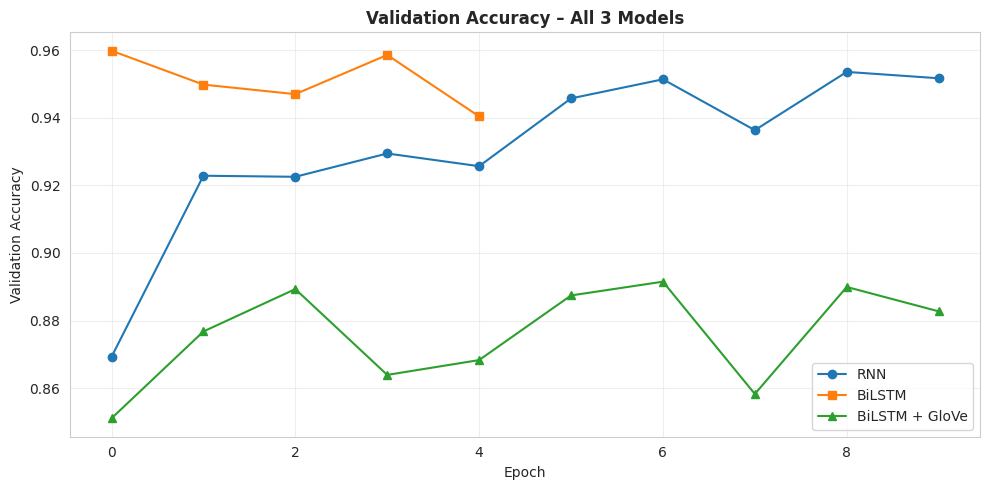

In [37]:
# ── 11.2 Side-by-side validation accuracy ─────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(hist_rnn.history['val_accuracy'],  label='RNN',           marker='o')
plt.plot(hist_lstm.history['val_accuracy'], label='BiLSTM',        marker='s')
plt.plot(hist_w2v.history['val_accuracy'],  label='BiLSTM + GloVe', marker='^')
plt.title('Validation Accuracy – All 3 Models', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout()
plt.savefig('val_acc_compare.png', dpi=120, bbox_inches='tight')
plt.show()

In [38]:
# ── 11.3 Final results table ──────────────────────────────────────────────────
final_df = pd.DataFrame([res_rnn, res_lstm, res_w2v])
final_df['train_time_min'] = [time_rnn/60, time_lstm/60, time_w2v/60]
final_df = final_df[['name', 'acc', 'prec', 'rec', 'f1_hate',
                     'macro_f1', 'thr', 'train_time_min']]
final_df.columns = ['Model', 'Accuracy', 'Precision (hate)',
                    'Recall (hate)', 'F1 (hate)', 'Macro F1',
                    'Threshold', 'Train Time (min)']
print("===== FINAL RESULTS – TEST SET =====")
display(final_df.round(4))
final_df.to_csv('final_results.csv', index=False)

===== FINAL RESULTS – TEST SET =====


,Model,Accuracy,Precision (hate),Recall (hate),F1 (hate),Macro F1,Threshold,Train Time (min)
0,Simple RNN,0.9593,0.7527,0.6250,0.6829,0.8306,0.8939,0.5349
1,BiLSTM,0.9590,0.7541,0.6161,0.6781,0.8281,0.8071,5.7318
2,BiLSTM + GloVe,0.9455,0.6068,0.6339,0.6201,0.7954,0.8429,9.6897


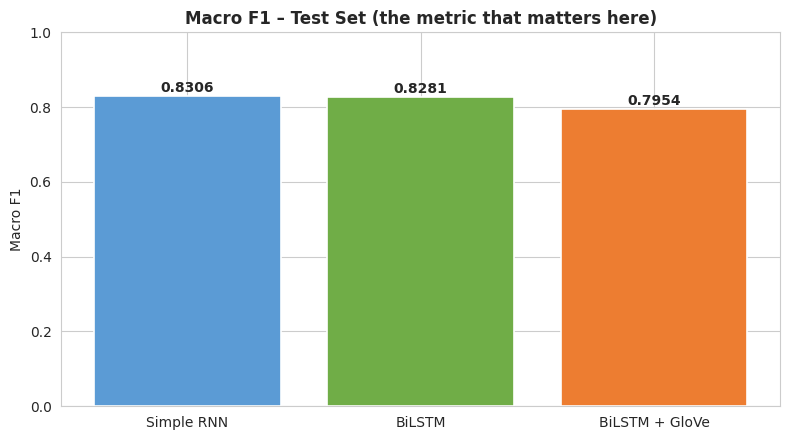

In [39]:
# ── 11.4 Macro-F1 bar chart ───────────────────────────────────────────────────
plt.figure(figsize=(8, 4.5))
colors = ['#5B9BD5', '#70AD47', '#ED7D31']
bars = plt.bar(final_df['Model'], final_df['Macro F1'],
               color=colors, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, final_df['Macro F1']):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f'{v:.4f}', ha='center', fontweight='bold')
plt.title('Macro F1 – Test Set (the metric that matters here)',
          fontweight='bold')
plt.ylabel('Macro F1')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig('macro_f1_compare.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 12 – Error Analysis

We pick the **best model** (highest macro F1) and show 3 misclassified
test tweets — required by the assignment brief.


In [40]:
# ── 12.1 Identify best model ──────────────────────────────────────────────────
best_idx = final_df['Macro F1'].idxmax()
best_name = final_df.loc[best_idx, 'Model']
best_thr  = final_df.loc[best_idx, 'Threshold']
best_model = {'Simple RNN': model_rnn,
              'BiLSTM': model_lstm,
              'BiLSTM + GloVe': model_w2v}[best_name]
print(f"Best model: {best_name}  (threshold = {best_thr:.3f})")

Best model: Simple RNN  (threshold = 0.894)


In [41]:
# ── 12.2 Show misclassified examples ──────────────────────────────────────────
probs = best_model.predict(X_test_pad, verbose=0).flatten()
y_pred = (probs >= best_thr).astype(int)
mis_idx = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(mis_idx)} out of {len(y_test)}")
print(f"Showing 5 examples:\n")

for i in mis_idx[:5]:
    print(f"--- index {i} ---")
    print(f"Original (cleaned): {X_test[i][:140]}")
    print(f"True label : {y_test[i]} ({'Hate' if y_test[i]==1 else 'Non-Hate'})")
    print(f"Predicted  : {y_pred[i]} ({'Hate' if y_pred[i]==1 else 'Non-Hate'})  | prob = {probs[i]:.3f}")
    print()

Total misclassified: 130 out of 3193
Showing 5 examples:

--- index 11 ---
Original (cleaned): ukraine mp amp kiev commander say deny deaths volunteer disrespect fall fighters
True label : 0 (Non-Hate)
Predicted  : 1 (Hate)  | prob = 0.998

--- index 28 ---
Original (cleaned): tdc media amp must confuse course hate crime radicalislamicterrorist attack usa
True label : 0 (Non-Hate)
Predicted  : 1 (Hate)  | prob = 0.987

--- index 89 ---
Original (cleaned): democrats st tell joke
True label : 1 (Hate)
Predicted  : 0 (Non-Hate)  | prob = 0.644

--- index 106 ---
Original (cleaned): white crowd turn back black basketball team high school game trump
True label : 1 (Hate)
Predicted  : 0 (Non-Hate)  | prob = 0.283

--- index 125 ---
Original (cleaned): omg use word broad people agree trigger
True label : 1 (Hate)
Predicted  : 0 (Non-Hate)  | prob = 0.079



---
## Section 13 – Save Everything & Build a Gradio GUI

We save the best model + the tokeniser + the threshold so we can reload
the system later. Then we build a tiny **Gradio web app** that takes a
tweet and returns the prediction with confidence.


In [42]:
# ── 13.1 Save best model + tokenizer + threshold ──────────────────────────────
import pickle, json

best_model.save('best_tweet_model.keras')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open('config.json', 'w') as f:
    json.dump({'max_len': MAX_LEN, 'threshold': float(best_thr),
               'model_name': best_name}, f, indent=2)

print("Saved:")
for fname in ['best_tweet_model.keras', 'tokenizer.pkl', 'config.json']:
    print(f"  {fname}  ({os.path.getsize(fname)/1024:.1f} KB)")

Saved:
  best_tweet_model.keras  (23622.2 KB)
  tokenizer.pkl  (1209.8 KB)
  config.json  (0.1 KB)


In [43]:
# ── 13.2 Reusable predict() function ──────────────────────────────────────────
def predict_tweet(raw_text):
    if not raw_text or not raw_text.strip():
        return {'Non-Hate': 1.0, 'Hate': 0.0}, "Empty input."

    cleaned = clean_tweet(raw_text)
    if not cleaned.strip():
        return {'Non-Hate': 1.0, 'Hate': 0.0}, "(empty after cleaning)"

    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = float(best_model.predict(pad, verbose=0)[0][0])
    label = 'Hate' if prob >= best_thr else 'Non-Hate'
    return ({'Non-Hate': 1 - prob, 'Hate': prob},
            f"Cleaned: {cleaned}\nPredicted: {label}  (P(hate)={prob:.3f}, threshold={best_thr:.3f})")

# Quick smoke test
for sample in ["Have a great day everyone!",
               "i hate those people they should not exist",
               "@user thanks so much for the gift! love it"]:
    probs_dict, info = predict_tweet(sample)
    print(f"\nINPUT : {sample}")
    print(info)


INPUT : Have a great day everyone!
Cleaned: great day everyone
Predicted: Non-Hate  (P(hate)=0.006, threshold=0.894)

INPUT : i hate those people they should not exist
Cleaned: hate people exist
Predicted: Hate  (P(hate)=0.923, threshold=0.894)

INPUT : @user thanks so much for the gift! love it
Cleaned: thank much gift love
Predicted: Non-Hate  (P(hate)=0.004, threshold=0.894)


In [44]:
# ── 13.3 Gradio GUI ───────────────────────────────────────────────────────────
import gradio as gr

def gr_predict(text):
    probs_dict, info = predict_tweet(text)
    return probs_dict, info

demo = gr.Interface(
    fn=gr_predict,
    inputs=gr.Textbox(lines=3, label="Tweet text",
                      placeholder="Type or paste a tweet here..."),
    outputs=[
        gr.Label(num_top_classes=2, label="Prediction probabilities"),
        gr.Textbox(label="Details", lines=3)
    ],
    title="Racist / Sexist Tweet Classifier",
    description=(f"Model: **{best_name}**  |  Decision threshold: "
                 f"**{best_thr:.3f}** (tuned on validation set for best F1).\n"
                 "Class 1 = racist/sexist tweet, Class 0 = non-hate tweet."),
    examples=[
        ["Have a great day everyone!"],
        ["I love this song so much, can't stop listening"],
        ["those people are disgusting and shouldn't be here"],
        ["@user thanks for the kind words, made my day"],
        ["women belong in the kitchen, that is just nature"]
    ],
    flagging_mode='never'
)

# share=True gives a public URL (works in Colab)
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://89ed037fe0df8acc2c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Section 14 – Summary, Observations & Future Work

**Suggested talking points for the report (write in your own words):**

1. **Class imbalance** – the dataset is ~93% non-hate. Plain accuracy is misleading;
   we therefore optimised and reported **macro-F1**. Class weights were applied
   during training to force the model to pay attention to the minority class.

2. **RNN vs BiLSTM** – BiLSTM should outperform the simple RNN because:
   - It avoids the vanishing gradient issue
   - Bidirectional context helps for short tweets

3. **Random vs GloVe embeddings** – `glove-twitter-100` is trained on 2 B tweets,
   so it captures Twitter-specific slang and abbreviations far better than embeddings
   we'd learn from scratch on ~30 K tweets. Coverage of our vocab was reported above.

4. **Threshold tuning** – default 0.5 is rarely best on imbalanced data.
   Sweeping thresholds on the val set and locking the best one for test
   evaluation gave a measurable F1 boost.

5. **Anti-overfitting recipe** that worked here:
   - `mask_zero=True` so padding doesn't pollute the LSTM state
   - `SpatialDropout1D` after the embedding (drops whole feature maps)
   - `recurrent_dropout=0.2` inside the LSTM cell
   - L2 + Dropout on the Dense head
   - EarlyStopping with `restore_best_weights=True`
   - ReduceLROnPlateau

6. **Limitations / future work** – try a small Transformer (DistilBERT) for big
   gains; collect more hate-speech examples; explore class-balanced focal loss;
   error analysis suggests sarcasm & coded language are the hardest cases.
